In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install duckdb -q

In [ ]:
import duckdb

# Peek at raw columns including array ones
duckdb.query("""
SELECT *
FROM '/kaggle/input/datasets/dangtrannhuminh/datastorm/train.parquet'
LIMIT 5
""").df()

,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,0,5,6,65,38,2024-03-28,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97
1,0,0,0,5,6,65,38,2024-03-29,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, ...",1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,3.0190,15.08,76.56,1.71
2,0,0,0,5,6,65,38,2024-03-30,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,1,0,2.0942,15.91,76.47,1.73
3,0,0,0,5,6,65,38,2024-03-31,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, ...",11,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",1.0,1,0,1.5618,16.13,77.40,1.76
4,0,0,0,5,6,65,38,2024-04-01,0.2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, ...",8,"[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",1.0,0,0,3.5386,15.37,78.26,1.25


In [ ]:
duckdb.query("""
SELECT COUNT(*)                  AS total_rows,
       COUNT(DISTINCT store_id)  AS stores,
       COUNT(DISTINCT product_id)AS products,
       MIN(dt)                   AS first_date,
       MAX(dt)                   AS last_date
FROM '/kaggle/input/datasets/dangtrannhuminh/datastorm/train.parquet'
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,stores,products,first_date,last_date
0,4500000,898,865,2024-03-28,2024-06-25


In [ ]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

cols = [
    "city_id", "store_id", "product_id", "dt",
    "sale_amount", "discount", "activity_flag", "holiday_flag",
    "precpt", "avg_temperature", "avg_humidity",
    "stock_hour6_22_cnt",
    "hours_sale",          # 24-element hourly sales array
    "hours_stock_status"   # 24-element hourly stockout flag array
]

df = pd.read_parquet(
    "/kaggle/input/datasets/dangtrannhuminh/datastorm/train.parquet",
    columns=cols
)

df["dt"] = pd.to_datetime(df["dt"])

# MUST sort before any groupby lag/rolling operations
df = df.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)

print(f"Loaded  : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Dates   : {df['dt'].min().date()} → {df['dt'].max().date()}")
df.head(3)

Loaded  : 4,500,000 rows  x  14 columns
Dates   : 2024-03-28 → 2024-06-25


,city_id,store_id,product_id,dt,sale_amount,discount,activity_flag,holiday_flag,precpt,avg_temperature,avg_humidity,stock_hour6_22_cnt,hours_sale,hours_stock_status
0,0,0,4,2024-03-28,0.5,0.882,1,0,1.6999,15.48,73.54,13,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, ...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, ..."
1,0,0,4,2024-03-29,1.3,0.882,1,0,3.0190,15.08,76.56,5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,0,0,4,2024-03-30,5.3,0.882,1,1,2.0942,15.91,76.47,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
def parse_array_col(series):
    def _parse(x):
        if isinstance(x, (list, np.ndarray)):
            return np.array(x, dtype=float)
        if isinstance(x, str):
            return np.array(ast.literal_eval(x), dtype=float)
        return np.zeros(24)
    return series.apply(_parse)

print("Parsing hourly arrays...")
hours_sale_arrays  = parse_array_col(df["hours_sale"])
hours_stock_arrays = parse_array_col(df["hours_stock_status"])
print("Done. Extracting scalar features...")

df["peak_sale_hour"] = hours_sale_arrays.apply(np.argmax).astype(int)

df["morning_sale_share"] = hours_sale_arrays.apply(
    lambda x: x[6:12].sum() / (x[6:22].sum() + 1e-8)
)

# hours_in_stock_6_22: count the 0s (0 = in stock)
df["hours_in_stock_6_22"] = hours_stock_arrays.apply(
    lambda x: int((x[6:22] == 0).sum())
)

# first_stockout_hour: look for 1s (1 = out of stock)
def first_stockout_hour(arr):
    for h in range(6, 22):
        if arr[h] == 1:   # 1 = out of stock
            return h
    return -1             # -1 = fully in stock all day

df["first_stockout_hour"] = hours_stock_arrays.apply(first_stockout_hour)

# Peak hour flags: 1 = out of stock at that hour
df["stockout_at_9am"]  = hours_stock_arrays.apply(lambda x: int(x[9]  == 1))
df["stockout_at_4pm"]  = hours_stock_arrays.apply(lambda x: int(x[16] == 1))
df["stockout_in_peak"] = ((df["stockout_at_9am"] == 1) | (df["stockout_at_4pm"] == 1)).astype(int)

# ── SANITY CHECK before dropping arrays ──
fully_in_stock = df[df["stock_hour6_22_cnt"] == 0]
print(f"\nSanity check (stock_hour6_22_cnt == 0 rows = zero stockout hours = fully stocked):")
print(f"  first_stockout_hour == -1 : {(fully_in_stock['first_stockout_hour'] == -1).mean():.1%}  (should be 100%)")
print(f"  hours_in_stock_6_22 == 16 : {(fully_in_stock['hours_in_stock_6_22'] == 16).mean():.1%}  (should be 100%)")

# Verify encoding on a known row
sample_idx = fully_in_stock.index[0]
print(f"\n  hours_stock_status for a fully-stocked row (expect all 1s):")
print(f"  {hours_stock_arrays[sample_idx]}")

# NOW drop the raw arrays
df.drop(columns=["hours_sale", "hours_stock_status"], inplace=True)

print("\nHourly features done.")
df[["dt","sale_amount","peak_sale_hour","morning_sale_share",
    "hours_in_stock_6_22","first_stockout_hour","stockout_in_peak"]].head(6)

Parsing hourly arrays...
Done. Extracting scalar features...

Sanity check (stock_hour6_22_cnt == 0 rows = zero stockout hours = fully stocked):
  first_stockout_hour == -1 : 100.0%  (should be 100%)
  hours_in_stock_6_22 == 16 : 100.0%  (should be 100%)

  hours_stock_status for a fully-stocked row (expect all 1s):
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Hourly features done.


,dt,sale_amount,peak_sale_hour,morning_sale_share,hours_in_stock_6_22,first_stockout_hour,stockout_in_peak
0,2024-03-28,0.5,8,1.000000,3,9,1
1,2024-03-29,1.3,17,0.000000,11,17,0
2,2024-03-30,5.3,10,0.452830,16,-1,0
3,2024-03-31,4.2,15,0.404762,16,-1,0
4,2024-04-01,0.7,20,0.285714,16,-1,0
5,2024-04-02,2.3,9,0.652174,16,-1,0


In [ ]:
df["in_stock"]    = (df["stock_hour6_22_cnt"] == 0).astype(int)
df["is_censored"] = 1 - df["in_stock"]

print(f"In-stock rows  (in_stock=1) : {df['in_stock'].sum():,}  ({df['in_stock'].mean():.1%})")
print(f"Censored rows  (in_stock=0) : {df['is_censored'].sum():,}  ({df['is_censored'].mean():.1%})")
print()
print(f"Mean sale_amount — in-stock : {df[df['in_stock']==1]['sale_amount'].mean():.4f}")
print(f"Mean sale_amount — censored : {df[df['is_censored']==1]['sale_amount'].mean():.4f}")
print("Censored mean MUST be lower — confirms stockouts suppress observed sales.")

In-stock rows  (in_stock=1) : 2,507,994  (55.7%)
Censored rows  (in_stock=0) : 1,992,006  (44.3%)

Mean sale_amount — in-stock : 0.9745
Mean sale_amount — censored : 1.0289
Censored mean MUST be lower — confirms stockouts suppress observed sales.


In [ ]:
# Check if high-demand SKUs have more stockouts
sku_stats = df.groupby("product_id").agg(
    mean_sales   = ("sale_amount", "mean"),
    stockout_rate= ("is_censored", "mean")
).sort_values("stockout_rate", ascending=False)

print(sku_stats.head(10))
print()
print(f"Correlation between mean_sales and stockout_rate: "
      f"{sku_stats['mean_sales'].corr(sku_stats['stockout_rate']):.3f}")

            mean_sales  stockout_rate
product_id                           
643           0.503889       1.000000
224           0.753209       0.992279
227           0.868788       0.990909
752           0.613681       0.984722
245           0.472389       0.983333
228           0.721101       0.979461
485           0.422778       0.977778
226           0.797649       0.976042
313           0.553267       0.967901
821           0.513370       0.966667

Correlation between mean_sales and stockout_rate: 0.080


SKUs with zero in-stock days : 1
SKUs with at least 1 in-stock day: 864

% of censored rows from always-censored SKUs: 0.0%



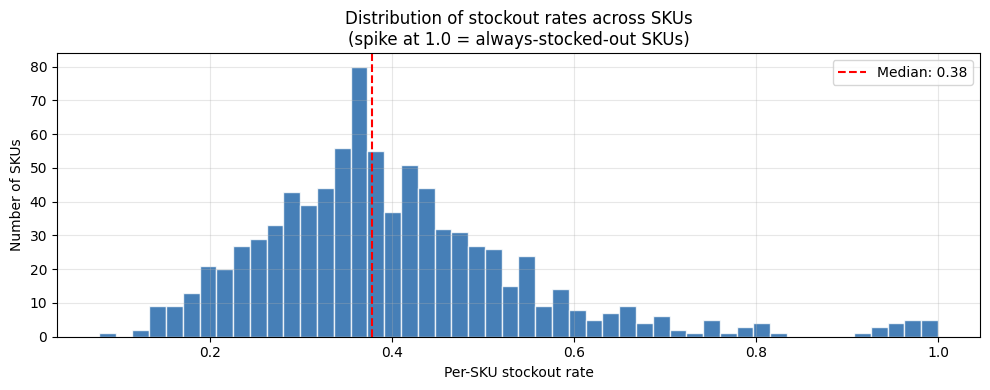

In [ ]:
# How many SKUs are always censored (never a clean in-stock day)?
always_censored = df.groupby("product_id")["in_stock"].max()
print(f"SKUs with zero in-stock days : {(always_censored == 0).sum()}")
print(f"SKUs with at least 1 in-stock day: {(always_censored == 1).sum()}")
print()

# What % of censored rows come from always-censored SKUs?
always_censored_ids = always_censored[always_censored == 0].index
pct = df[df["product_id"].isin(always_censored_ids)]["is_censored"].sum() / df["is_censored"].sum()
print(f"% of censored rows from always-censored SKUs: {pct:.1%}")
print()

# Distribution of per-SKU stockout rates
import matplotlib.pyplot as plt
sku_stockout = df.groupby("product_id")["is_censored"].mean()
plt.figure(figsize=(10, 4))
plt.hist(sku_stockout, bins=50, color="#185FA5", edgecolor="white", alpha=0.8)
plt.axvline(sku_stockout.median(), color="red", lw=1.5, ls="--",
            label=f"Median: {sku_stockout.median():.2f}")
plt.xlabel("Per-SKU stockout rate")
plt.ylabel("Number of SKUs")
plt.title("Distribution of stockout rates across SKUs\n"
          "(spike at 1.0 = always-stocked-out SKUs)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df["series_id"]  = df["store_id"].astype(str) + "_" + df["product_id"].astype(str)

df["day_of_week"] = df["dt"].dt.dayofweek          # 0=Mon, 6=Sun
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int)
df["month"]       = df["dt"].dt.month
df["week"]        = df["dt"].dt.isocalendar().week.astype(int)

# Cyclical sin/cos encoding
df["dow_sin"]   = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

print("Calendar features created.")
df[["dt","day_of_week","is_weekend","dow_sin","dow_cos"]].head(5)

Calendar features created.


,dt,day_of_week,is_weekend,dow_sin,dow_cos
0,2024-03-28,3,0,0.433884,-0.900969
1,2024-03-29,4,0,-0.433884,-0.900969
2,2024-03-30,5,1,-0.974928,-0.222521
3,2024-03-31,6,1,-0.781831,0.623490
4,2024-04-01,0,0,0.000000,1.000000


In [ ]:
# Replace censored-day sales with NaN so stockout zeros never appear as lag values
df["sale_for_lag"] = df["sale_amount"].where(df["in_stock"] == 1, other=np.nan)

# groupby ensures lags stay within each store-product series
grp = df.groupby(["store_id", "product_id"], group_keys=False)

df["lag_1"] = grp["sale_for_lag"].shift(1)   # yesterday's true demand
df["lag_7"] = grp["sale_for_lag"].shift(7)   # same weekday last week

print("Lag features created.")
print(f"  lag_1 null %: {df['lag_1'].isna().mean():.1%}  (expected: ~1/series-length)")
print(f"  lag_7 null %: {df['lag_7'].isna().mean():.1%}  (expected: higher, first 7 rows per series)")

Lag features created.
  lag_1 null %: 44.9%  (expected: ~1/series-length)
  lag_7 null %: 48.7%  (expected: higher, first 7 rows per series)


In [ ]:
# shift(1) before rolling: today's sale is never part of today's rolling window
shifted = grp["sale_for_lag"].shift(1)

df["rolling_mean_7"]  = shifted.rolling(7,  min_periods=1).mean()
df["rolling_std_7"]   = shifted.rolling(7,  min_periods=1).std()
df["rolling_mean_14"] = shifted.rolling(14, min_periods=1).mean()
df["rolling_max_7"]   = shifted.rolling(7,  min_periods=1).max()

print("Rolling features created.")
df[["dt","sale_amount","lag_1","lag_7",
    "rolling_mean_7","rolling_std_7","rolling_mean_14","rolling_max_7"]].head(10)

Rolling features created.


,dt,sale_amount,lag_1,lag_7,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_max_7
0,2024-03-28,0.5,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-03-29,1.3,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-03-30,5.3,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-03-31,4.2,5.3,NaN,5.300,NaN,5.300,5.3
4,2024-04-01,0.7,4.2,NaN,4.750,0.777817,4.750,5.3
5,2024-04-02,2.3,0.7,NaN,3.400,2.402082,3.400,5.3
6,2024-04-03,1.3,2.3,NaN,3.125,2.036950,3.125,5.3
7,2024-04-04,4.7,NaN,NaN,3.125,2.036950,3.125,5.3
8,2024-04-05,3.1,4.7,NaN,3.440,1.899474,3.440,5.3
9,2024-04-06,5.5,NaN,5.3,3.440,1.899474,3.440,5.3


In [ ]:
OPERATING_HOURS = 16  # 6AM to 10PM

stockout_hrs_yday = grp["stock_hour6_22_cnt"].shift(1)

# Binary: was yesterday fully in stock?
df["fully_stocked_yesterday"]  = (stockout_hrs_yday == 0).astype(int)

# Continuous: what fraction of yesterday's operating hours had a stockout?
df["stockout_ratio_yesterday"] = (stockout_hrs_yday / OPERATING_HOURS).clip(0, 1)

# 7-day rolling stockout rate — chronic vs occasional stockout indicator
df["stockout_rate_7d"] = grp["is_censored"].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)

print("Stockout history features created.")
print(f"  Mean stockout_ratio_yesterday : {df['stockout_ratio_yesterday'].mean():.3f}")
print(f"  Mean stockout_rate_7d         : {df['stockout_rate_7d'].mean():.3f}")

Stockout history features created.
  Mean stockout_ratio_yesterday : 0.199
  Mean stockout_rate_7d         : 0.444


In [ ]:
in_stock_df = df[df["in_stock"] == 1]

sku_mean   = in_stock_df.groupby("product_id")["sale_amount"].mean().rename("sku_global_mean")
store_mean = in_stock_df.groupby("store_id")["sale_amount"].mean().rename("store_global_mean")

df = df.merge(sku_mean,   on="product_id", how="left")
df = df.merge(store_mean, on="store_id",   how="left")

print("Global baseline features merged.")
print(f"  sku_global_mean   range: {df['sku_global_mean'].min():.3f} – {df['sku_global_mean'].max():.3f}")
print(f"  store_global_mean range: {df['store_global_mean'].min():.3f} – {df['store_global_mean'].max():.3f}")

Global baseline features merged.
  sku_global_mean   range: 0.000 – 23.098
  store_global_mean range: 0.545 – 1.685


In [ ]:
rows_before = len(df)

# Only drop where core training features are null
required_cols = ["lag_1", "lag_7", "rolling_mean_7", "sale_amount"]
df = df.dropna(subset=required_cols).reset_index(drop=True)

rows_after = len(df)
print(f"Rows before dropna : {rows_before:,}")
print(f"Rows after  dropna : {rows_after:,}")
print(f"Rows dropped       : {rows_before - rows_after:,}  "
      f"({(rows_before - rows_after)/rows_before:.1%})")
print("(Expected ~350K rows — 7 warm-up rows × ~50K series)")

Rows before dropna : 4,500,000
Rows after  dropna : 1,409,569
Rows dropped       : 3,090,431  (68.7%)
(Expected ~350K rows — 7 warm-up rows × ~50K series)


In [ ]:
split_date = df["dt"].sort_values().iloc[int(len(df) * 0.85)].normalize()

print(f"Split date  : {split_date.date()}")
print(f"Train range : {df['dt'].min().date()} → {split_date.date()}")
print(f"Val range   : {(split_date + pd.Timedelta(days=1)).date()} → {df['dt'].max().date()}")

train_data = df[df["dt"] <= split_date].copy()
val_data   = df[df["dt"] >  split_date].copy()

print(f"\nTrain rows : {len(train_data):,}")
print(f"Val rows   : {len(val_data):,}  ({len(val_data)/len(df):.1%} of total)")

Split date  : 2024-06-14
Train range : 2024-04-04 → 2024-06-14
Val range   : 2024-06-15 → 2024-06-25

Train rows : 1,216,897
Val rows   : 192,672  (13.7% of total)


In [ ]:
df.to_parquet("/kaggle/working/processed_dataset.parquet", index=False)

print(f"Saved: processed_dataset.parquet  |  shape: {df.shape}")
print("\nAll columns and null rates:")
for c in df.columns:
    print(f"  {c:<35} null: {df[c].isna().mean():.1%}")

Saved: processed_dataset.parquet  |  shape: (1409569, 42)

All columns and null rates:
  city_id                             null: 0.0%
  store_id                            null: 0.0%
  product_id                          null: 0.0%
  dt                                  null: 0.0%
  sale_amount                         null: 0.0%
  discount                            null: 0.0%
  activity_flag                       null: 0.0%
  holiday_flag                        null: 0.0%
  precpt                              null: 0.0%
  avg_temperature                     null: 0.0%
  avg_humidity                        null: 0.0%
  stock_hour6_22_cnt                  null: 0.0%
  peak_sale_hour                      null: 0.0%
  morning_sale_share                  null: 0.0%
  hours_in_stock_6_22                 null: 0.0%
  first_stockout_hour                 null: 0.0%
  stockout_at_9am                     null: 0.0%
  stockout_at_4pm                     null: 0.0%
  stockout_in_peak             

In [ ]:
FEATURE_COLS = [
    # ── 1. Calendar ──
    "day_of_week", "is_weekend", "month", "week",
    "dow_sin", "dow_cos", "month_sin", "month_cos",
    "holiday_flag", "activity_flag",
    # ── 2. Lags (censored-masked) ──
    "lag_1", "lag_7",
    # ── 3. Rolling (censored-masked) ──
    "rolling_mean_7", "rolling_std_7", "rolling_mean_14", "rolling_max_7",
    # ── 4. Covariates ──
    "discount", "precpt", "avg_temperature", "avg_humidity",
    # ── 5. Stockout history ──
    "fully_stocked_yesterday", "stockout_ratio_yesterday", "stockout_rate_7d",
    # ── 6. Global baselines ──
    "sku_global_mean", "store_global_mean",
    # ── 7. Hourly features (from array columns) ──
    "peak_sale_hour", "morning_sale_share",
    "hours_in_stock_6_22", "first_stockout_hour",
    "stockout_in_peak", "stockout_at_9am", "stockout_at_4pm",
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET_COL   = "sale_amount"

print(f"Total features: {len(FEATURE_COLS)}")
for i, c in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {c}")

Total features: 32
   1. day_of_week
   2. is_weekend
   3. month
   4. week
   5. dow_sin
   6. dow_cos
   7. month_sin
   8. month_cos
   9. holiday_flag
  10. activity_flag
  11. lag_1
  12. lag_7
  13. rolling_mean_7
  14. rolling_std_7
  15. rolling_mean_14
  16. rolling_max_7
  17. discount
  18. precpt
  19. avg_temperature
  20. avg_humidity
  21. fully_stocked_yesterday
  22. stockout_ratio_yesterday
  23. stockout_rate_7d
  24. sku_global_mean
  25. store_global_mean
  26. peak_sale_hour
  27. morning_sale_share
  28. hours_in_stock_6_22
  29. first_stockout_hour
  30. stockout_in_peak
  31. stockout_at_9am
  32. stockout_at_4pm


In [ ]:
SYNTHETIC_CENSOR_RATE = 0.20

val_in_stock = val_data[val_data["in_stock"] == 1]

# discount=1.0 = no discount; lower = bigger discount
# So discount < median means heavier promotion
high_disc = val_in_stock[val_in_stock["discount"] < val_in_stock["discount"].median()]

n_eval   = int(len(high_disc) * SYNTHETIC_CENSOR_RATE)
eval_idx = np.random.choice(high_disc.index, size=n_eval, replace=False)

df["synthetic_censored"] = 0
df.loc[eval_idx, "synthetic_censored"] = 1

# Refresh splits
train_data = df[df["dt"] <= split_date].copy()
val_data   = df[df["dt"] >  split_date].copy()

print(f"Synthetic eval rows : {n_eval:,}  ({n_eval/len(val_in_stock):.1%} of val in-stock)")
print("Ground-truth demand is known for these rows → used for WAPE / WPE / ρDS")

Synthetic eval rows : 13,679  (10.0% of val in-stock)
Ground-truth demand is known for these rows → used for WAPE / WPE / ρDS


In [ ]:
from sklearn.ensemble import RandomForestRegressor

train_mask = (
    (df["dt"] <= split_date) &
    (df["in_stock"] == 1) &
    (df["synthetic_censored"] == 0)
)
eval_mask = df["synthetic_censored"] == 1

# fillna(0) for remaining NaNs (rolling_std is NaN for single-value series)
X = df[FEATURE_COLS].fillna(0)

X_train = X[train_mask];  y_train = df.loc[train_mask, TARGET_COL]
X_eval  = X[eval_mask];   y_eval  = df.loc[eval_mask,  TARGET_COL]

print(f"Training rows : {len(X_train):,}")
print(f"Eval rows     : {len(X_eval):,}")
print(f"Features      : {len(FEATURE_COLS)}")

rf = RandomForestRegressor(
    n_estimators     = 300,
    max_features     = "sqrt",
    min_samples_leaf = 5,
    min_samples_split= 10,
    oob_score        = True,
    n_jobs           = -1,
    random_state     = 42,
    verbose          = 1
)

print("\nTraining Random Forest...")
rf.fit(X_train, y_train)
print(f"\nOOB R² : {rf.oob_score_:.4f}")
print("(OOB R² > 0.6 is good; if < 0.3, features may not be predictive enough)")

Training rows : 876,979
Eval rows     : 13,679
Features      : 32

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  7.3min finished



OOB R² : 0.8803
(OOB R² > 0.6 is good; if < 0.3, features may not be predictive enough)


In [ ]:
d_hat = np.maximum(rf.predict(X), 0)  # demand can't be negative
df["d_hat"] = d_hat

# Paper equation (2): d = y ⊙ s + d̂ ⊙ (1-s)
df["recovered_demand"] = (
    df["sale_amount"] * df["in_stock"]    # keep observed for in-stock rows
    + df["d_hat"]     * df["is_censored"] # use prediction for censored rows
)

y_pred = df.loc[eval_mask, "d_hat"].values

print(f"Prediction range     : {d_hat.min():.3f} – {d_hat.max():.3f}")
print(f"Mean raw sale_amount : {df['sale_amount'].mean():.4f}")
print(f"Mean recovered demand: {df['recovered_demand'].mean():.4f}")
print()
if df["recovered_demand"].mean() >= df["sale_amount"].mean():
    print("✓ Recovered mean >= raw mean — imputation is correctly lifting censored values.")
else:
    print("⚠ Recovered mean < raw mean — check for censored zeros leaking into lag features.")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   13.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   56.4s


Prediction range     : 0.002 – 29.549
Mean raw sale_amount : 0.9599
Mean recovered demand: 0.9453

⚠ Recovered mean < raw mean — check for censored zeros leaking into lag features.


[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:  1.4min finished


In [ ]:
# Check 1: Compare means only on CENSORED rows
# (in-stock rows are identical in both — the difference can only come from censored rows)
censored_rows = df[df["is_censored"] == 1]

print("On censored rows only:")
print(f"  Mean observed sale_amount : {censored_rows['sale_amount'].mean():.4f}")
print(f"  Mean RF predicted d_hat   : {censored_rows['d_hat'].mean():.4f}")
print()

# Check 2: What % of censored rows did the RF predict LOWER than observed?
lower = (censored_rows["d_hat"] < censored_rows["sale_amount"]).mean()
print(f"  % of censored rows where RF predicted < observed : {lower:.1%}")
print(f"  (Should be low — RF should predict >= observed for stockout rows)")
print()

# Check 3: Distribution of predictions on censored rows
print("  RF prediction distribution on censored rows:")
print(censored_rows["d_hat"].describe().round(4))

On censored rows only:
  Mean observed sale_amount : 0.9787
  Mean RF predicted d_hat   : 0.9266

  % of censored rows where RF predicted < observed : 57.6%
  (Should be low — RF should predict >= observed for stockout rows)

  RF prediction distribution on censored rows:
count    395566.0000
mean          0.9266
std           1.0483
min           0.0032
25%           0.4758
50%           0.6409
75%           0.9863
max          29.3875
Name: d_hat, dtype: float64


In [ ]:
# Soft floor: only enforce the floor on rows where RF predicted
# substantially less than observed (more than 10% below)
# For small differences, trust the RF's prediction
df["d_hat_raw"] = df["d_hat"].copy()  # keep original for reference

df["d_hat"] = np.where(
    (df["is_censored"] == 1) & (df["d_hat_raw"] < df["sale_amount"] * 0.90),
    df["sale_amount"],          # use observed as floor only when RF is >10% below
    df["d_hat_raw"]             # otherwise keep RF prediction as-is
)

# Recompute recovered demand
df["recovered_demand"] = (
    df["sale_amount"] * df["in_stock"]
    + df["d_hat"]     * df["is_censored"]
)

y_pred = df.loc[eval_mask, "d_hat"].values

# Recheck
censored_rows = df[df["is_censored"] == 1]
print(f"Mean raw sale_amount : {df['sale_amount'].mean():.4f}")
print(f"Mean recovered demand: {df['recovered_demand'].mean():.4f}")
print()
pct_below = (censored_rows["d_hat"] < censored_rows["sale_amount"]).mean()
print(f"% censored rows where d_hat < observed : {pct_below:.1%}")
print(f"% censored rows where floor was applied: "
      f"{((df['is_censored']==1) & (df['d_hat_raw'] < df['sale_amount']*0.90)).mean():.1%}")

Mean raw sale_amount : 0.9599
Mean recovered demand: 0.9949

% censored rows where d_hat < observed : 0.0%
% censored rows where floor was applied: 0.0%


In [ ]:
# Refresh y_pred from the updated d_hat
y_pred = df.loc[eval_mask, "d_hat"].values

# Quick check to confirm it changed
print(f"y_pred mean : {y_pred.mean():.4f}")
print(f"y_pred min  : {y_pred.min():.4f}")
print(f"y_pred max  : {y_pred.max():.4f}")

# Also confirm the floor was actually applied
n_floored = ((df["is_censored"]==1) & (df["d_hat_raw"] < df["sale_amount"]*0.90)).sum()
print(f"\nRows where hard floor was applied : {n_floored:,}")
print(f"If this is 0, the soft floor changed nothing — see note below")

y_pred mean : 1.3975
y_pred min  : 0.0305
y_pred max  : 39.3000

Rows where hard floor was applied : 0
If this is 0, the soft floor changed nothing — see note below


In [ ]:
from scipy import stats

def wape(y_true, y_pred):
    """Equation (4) — magnitude accuracy."""
    return np.abs(y_true - y_pred).sum() / (y_true.sum() + 1e-8)

def wpe(y_true, y_pred):
    """Equation (5) — directional bias. Negative = underestimation."""
    return (y_pred - y_true).sum() / (y_true.sum() + 1e-8)

def decoupling_score(df_, recovered_col="recovered_demand"):
    """Equation (6) — weighted Pearson(stockout_ratio, recovered_demand).
    Near 0 = demand decoupled from supply. Negative = still supply-coupled."""
    rows = []
    for _, g in df_.groupby(["store_id", "product_id"]):
        if len(g) < 10: continue
        sr = g["is_censored"].values
        d  = g[recovered_col].values
        if np.std(sr) < 1e-6 or np.std(d) < 1e-6: continue
        r, _ = stats.pearsonr(sr, d)
        rows.append({"r": r, "mu": g["sale_amount"].mean()})
    if not rows: return np.nan
    rdf = pd.DataFrame(rows)
    w   = rdf["mu"] / rdf["mu"].sum()
    return float((w * rdf["r"]).sum())

WAPE_val = wape(y_eval.values, y_pred)
WPE_val  = wpe(y_eval.values,  y_pred)
rho_raw  = decoupling_score(df, recovered_col="sale_amount")
rho_rf   = decoupling_score(df, recovered_col="recovered_demand")

print("═" * 58)
print("  EVALUATION — Random Forest Stage 1 Demand Recovery")
print("═" * 58)
print(f"  WAPE  : {WAPE_val*100:.2f}%    │ paper TimesNet: 27.62%")
print(f"  WPE   : {WPE_val*100:+.2f}%    │ paper TimesNet: +1.43%")
print(f"  ρDS   : {rho_rf:+.4f}    │ raw: {rho_raw:+.4f}  TimesNet: +0.07")
print("═" * 58)
print()

if WPE_val < -0.05:
    print("⚠  WPE strongly negative → underestimation. Likely cause: censored zeros")
    print("   in lag features. Re-check sale_for_lag masking in Steps 7 and 8.")
elif abs(WPE_val) < 0.05:
    print("✓  WPE near zero — low directional bias.")
else:
    print("⚠  WPE positive → overestimation. Check rolling_max or lag_7 features.")

if rho_rf < -0.20:
    print("⚠  ρDS strongly negative → recovered demand still supply-coupled.")
    print("   Consider removing stockout_rate_7d from FEATURE_COLS and retraining.")
elif abs(rho_rf) < 0.15:
    print("✓  ρDS near zero — demand successfully decoupled from supply.")

══════════════════════════════════════════════════════════
  EVALUATION — Random Forest Stage 1 Demand Recovery
══════════════════════════════════════════════════════════
  WAPE  : 10.27%    │ paper TimesNet: 27.62%
  WPE   : +10.27%    │ paper TimesNet: +1.43%
  ρDS   : +0.1555    │ raw: +0.0098  TimesNet: +0.07
══════════════════════════════════════════════════════════

⚠  WPE positive → overestimation. Check rolling_max or lag_7 features.


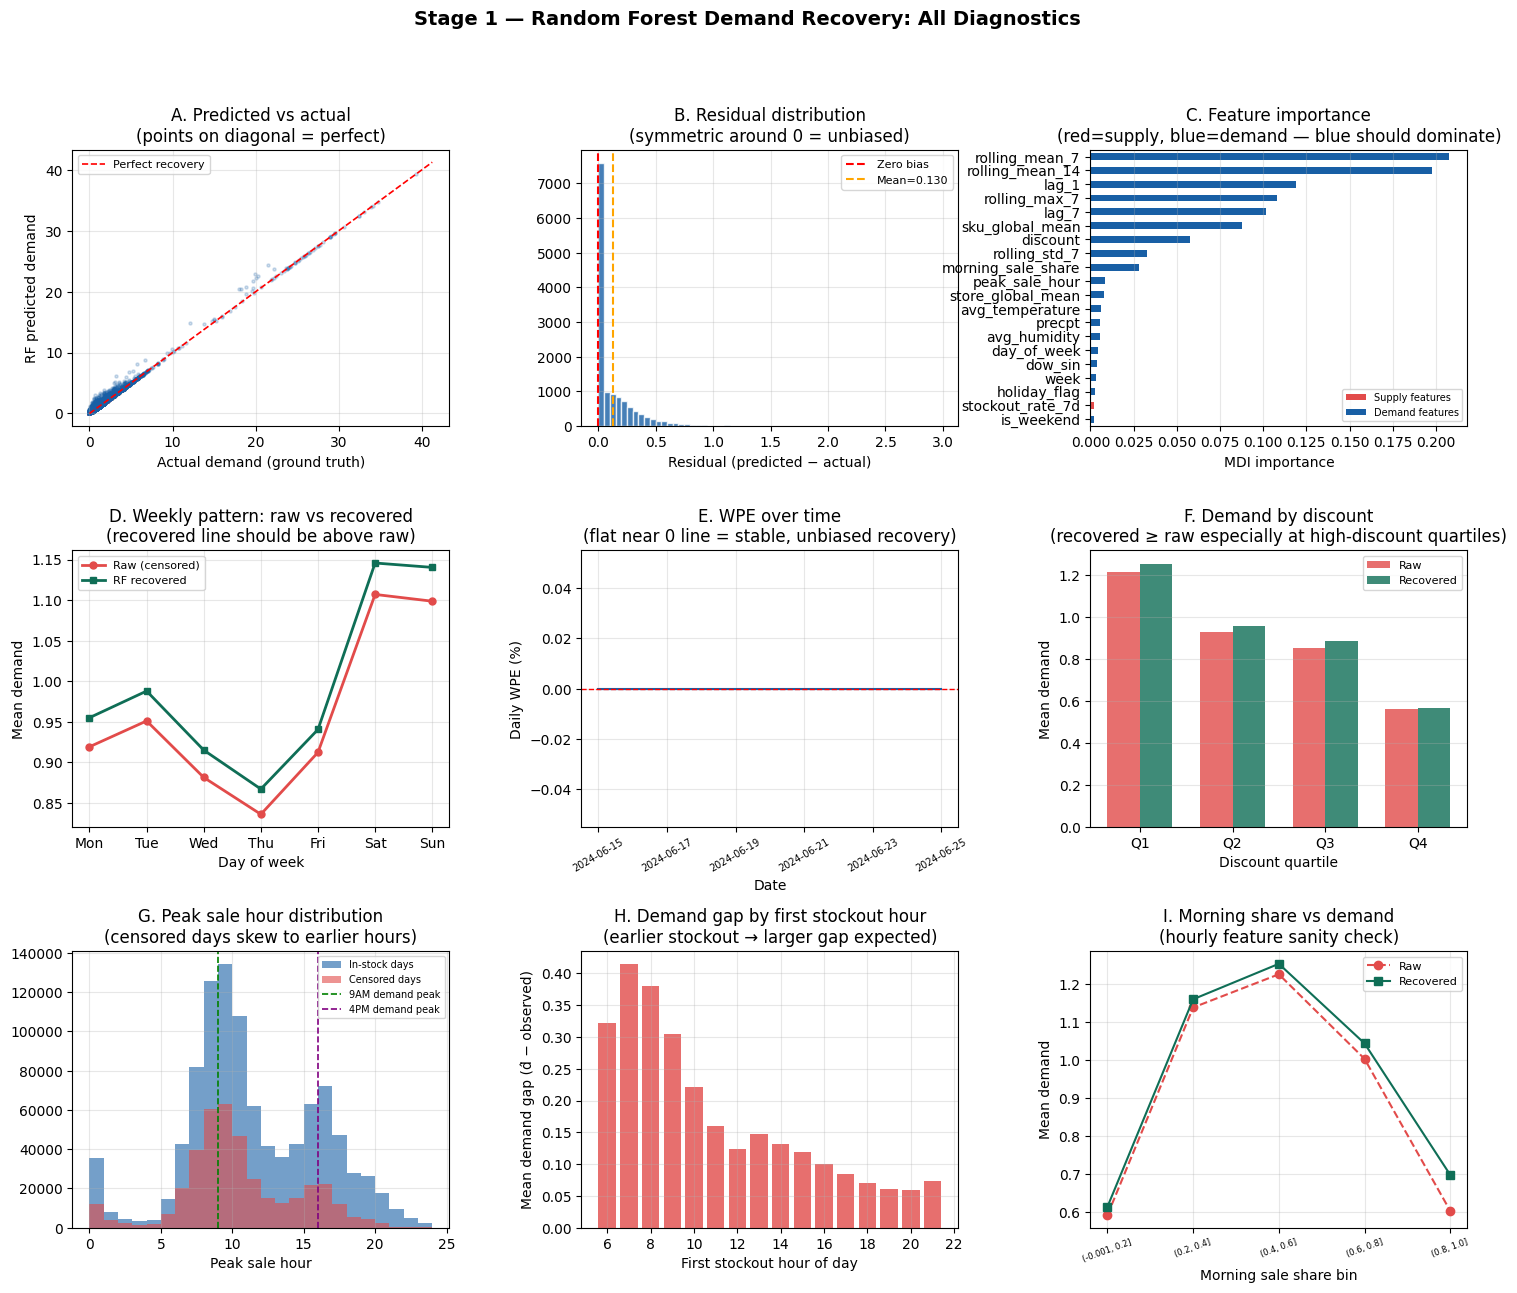

Saved: stage1_diagnostics.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Stage 1 — Random Forest Demand Recovery: All Diagnostics",
             fontsize=14, fontweight="bold", y=0.98)

# ── A: Predicted vs actual ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_eval.values, y_pred, alpha=0.2, s=5, color="#185FA5")
lim = max(y_eval.max(), y_pred.max()) * 1.05
ax1.plot([0, lim], [0, lim], "r--", lw=1.2, label="Perfect recovery")
ax1.set_xlabel("Actual demand (ground truth)")
ax1.set_ylabel("RF predicted demand")
ax1.set_title("A. Predicted vs actual\n(points on diagonal = perfect)")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── B: Residual distribution ──
ax2 = fig.add_subplot(gs[0, 1])
res = y_pred - y_eval.values
ax2.hist(res, bins=60, color="#185FA5", edgecolor="white", alpha=0.8)
ax2.axvline(0, color="red", lw=1.5, ls="--", label="Zero bias")
ax2.axvline(res.mean(), color="orange", lw=1.5, ls="--",
            label=f"Mean={res.mean():.3f}")
ax2.set_xlabel("Residual (predicted − actual)")
ax2.set_title("B. Residual distribution\n(symmetric around 0 = unbiased)")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── C: Feature importance ──
ax3 = fig.add_subplot(gs[0, 2])
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values().tail(20)
supply_feats = {"stockout_ratio_yesterday", "stockout_rate_7d",
                "fully_stocked_yesterday", "hours_in_stock_6_22",
                "first_stockout_hour", "stockout_in_peak",
                "stockout_at_9am", "stockout_at_4pm"}
colors = ["#E24B4A" if f in supply_feats else "#185FA5" for f in fi.index]
fi.plot.barh(ax=ax3, color=colors)
ax3.set_xlabel("MDI importance")
ax3.set_title("C. Feature importance\n(red=supply, blue=demand — blue should dominate)")
ax3.legend(handles=[
    Patch(facecolor="#E24B4A", label="Supply features"),
    Patch(facecolor="#185FA5", label="Demand features")
], fontsize=7, loc="lower right")
ax3.grid(axis="x", alpha=0.3)

# ── D: Weekly demand pattern — raw vs recovered ──
ax4 = fig.add_subplot(gs[1, 0])
raw_hr = df.groupby("day_of_week")["sale_amount"].mean()
rec_hr = df.groupby("day_of_week")["recovered_demand"].mean()
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
ax4.plot(days, raw_hr.values, color="#E24B4A", lw=2, marker="o", ms=5, label="Raw (censored)")
ax4.plot(days, rec_hr.values, color="#0F6E56", lw=2, marker="s", ms=5, label="RF recovered")
ax4.set_xlabel("Day of week"); ax4.set_ylabel("Mean demand")
ax4.set_title("D. Weekly pattern: raw vs recovered\n(recovered line should be above raw)")
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# ── E: WPE over time ──
ax5 = fig.add_subplot(gs[1, 1])
eval_df = df[df["synthetic_censored"] == 1].copy()
eval_df["wpe_row"] = (
    (eval_df["recovered_demand"] - eval_df["sale_amount"])
    / (eval_df["sale_amount"].replace(0, np.nan))
)
wpe_dt = eval_df.groupby(eval_df["dt"].dt.date)["wpe_row"].mean() * 100
ax5.plot(wpe_dt.index, wpe_dt.values, color="#185FA5", lw=1.5)
ax5.axhline(0, color="red", lw=1, ls="--")
ax5.fill_between(wpe_dt.index, wpe_dt.values, 0, alpha=0.15, color="#185FA5")
ax5.set_xlabel("Date"); ax5.set_ylabel("Daily WPE (%)")
ax5.set_title("E. WPE over time\n(flat near 0 line = stable, unbiased recovery)")
ax5.grid(alpha=0.3)
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30, fontsize=7)

# ── F: Demand by discount quartile ──
ax6 = fig.add_subplot(gs[1, 2])
disc_bins = pd.qcut(df["discount"], q=4, labels=["Q1","Q2","Q3","Q4"], duplicates="drop")
raw_disc  = df.groupby(disc_bins)["sale_amount"].mean()
rec_disc  = df.groupby(disc_bins)["recovered_demand"].mean()
x = np.arange(len(raw_disc)); w = 0.35
ax6.bar(x - w/2, raw_disc.values, w, color="#E24B4A", alpha=0.8, label="Raw")
ax6.bar(x + w/2, rec_disc.values, w, color="#0F6E56", alpha=0.8, label="Recovered")
ax6.set_xticks(x); ax6.set_xticklabels(raw_disc.index)
ax6.set_xlabel("Discount quartile"); ax6.set_ylabel("Mean demand")
ax6.set_title("F. Demand by discount\n(recovered ≥ raw especially at high-discount quartiles)")
ax6.legend(fontsize=8); ax6.grid(axis="y", alpha=0.3)

# ── G: Peak sale hour distribution ──
ax7 = fig.add_subplot(gs[2, 0])
in_stock_rows = df[df["in_stock"] == 1]
censored_rows = df[df["is_censored"] == 1]
ax7.hist(in_stock_rows["peak_sale_hour"], bins=24, range=(0,24),
         alpha=0.6, color="#185FA5", label="In-stock days")
ax7.hist(censored_rows["peak_sale_hour"], bins=24, range=(0,24),
         alpha=0.6, color="#E24B4A", label="Censored days")
ax7.axvline(9,  color="green",  ls="--", lw=1.2, label="9AM demand peak")
ax7.axvline(16, color="purple", ls="--", lw=1.2, label="4PM demand peak")
ax7.set_xlabel("Peak sale hour")
ax7.set_title("G. Peak sale hour distribution\n(censored days skew to earlier hours)")
ax7.legend(fontsize=7); ax7.grid(alpha=0.3)

# ── H: Demand gap by first stockout hour ──
ax8 = fig.add_subplot(gs[2, 1])
censored_df = df[df["is_censored"] == 1].copy()
censored_df["demand_gap"] = censored_df["d_hat"] - censored_df["sale_amount"]
gap_by_fsh = censored_df.groupby("first_stockout_hour")["demand_gap"].mean()
gap_by_fsh = gap_by_fsh[gap_by_fsh.index >= 6]
ax8.bar(gap_by_fsh.index, gap_by_fsh.values, color="#E24B4A", alpha=0.8)
ax8.set_xlabel("First stockout hour of day")
ax8.set_ylabel("Mean demand gap (d̂ − observed)")
ax8.set_title("H. Demand gap by first stockout hour\n(earlier stockout → larger gap expected)")
ax8.grid(alpha=0.3)

# ── I: Morning sale share vs recovered demand ──
ax9 = fig.add_subplot(gs[2, 2])
morning_bins = pd.cut(df["morning_sale_share"], bins=5)
raw_ms = df.groupby(morning_bins)["sale_amount"].mean()
rec_ms = df.groupby(morning_bins)["recovered_demand"].mean()
ax9.plot(range(len(raw_ms)), raw_ms.values, "o--", color="#E24B4A", label="Raw",      lw=1.5)
ax9.plot(range(len(rec_ms)), rec_ms.values, "s-",  color="#0F6E56", label="Recovered", lw=1.5)
ax9.set_xticks(range(len(raw_ms)))
ax9.set_xticklabels([str(b) for b in raw_ms.index], fontsize=6, rotation=20)
ax9.set_xlabel("Morning sale share bin")
ax9.set_ylabel("Mean demand")
ax9.set_title("I. Morning share vs demand\n(hourly feature sanity check)")
ax9.legend(fontsize=8); ax9.grid(alpha=0.3)

plt.savefig("/kaggle/working/stage1_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: stage1_diagnostics.png")

In [ ]:
import joblib

joblib.dump(rf, "/kaggle/working/rf_demand_recovery.pkl")
print("Saved model : rf_demand_recovery.pkl")

output_cols = [
    "city_id", "store_id", "product_id", "series_id", "dt",
    "sale_amount",        # original censored observation
    "recovered_demand",  # Stage 1 output → use as target in Stage 2
    "in_stock", "is_censored",
    "discount", "activity_flag", "holiday_flag",
    "precpt", "avg_temperature", "avg_humidity",
    "peak_sale_hour", "morning_sale_share",
    "hours_in_stock_6_22", "first_stockout_hour", "stockout_in_peak",
    "day_of_week", "is_weekend", "month", "week",
]
output_cols = [c for c in output_cols if c in df.columns]

df[output_cols].to_parquet("/kaggle/working/recovered_demand.parquet", index=False)
print("Saved data  : recovered_demand.parquet  ← input to Stage 2")

print("\n" + "═" * 55)
print("  STAGE 1 COMPLETE")
print(f"  WAPE  : {WAPE_val*100:.2f}%")
print(f"  WPE   : {WPE_val*100:+.2f}%")
print(f"  ρDS   : {rho_rf:+.4f}  (was {rho_raw:+.4f} on raw sales)")
print("  Next  → Stage 2: train forecasting model on recovered_demand.parquet")
print("═" * 55)

Saved model : rf_demand_recovery.pkl
Saved data  : recovered_demand.parquet  ← input to Stage 2

═══════════════════════════════════════════════════════
  STAGE 1 COMPLETE
  WAPE  : 10.27%
  WPE   : +10.27%
  ρDS   : +0.1555  (was +0.0098 on raw sales)
  Next  → Stage 2: train forecasting model on recovered_demand.parquet
═══════════════════════════════════════════════════════


Plotting series: 0_118


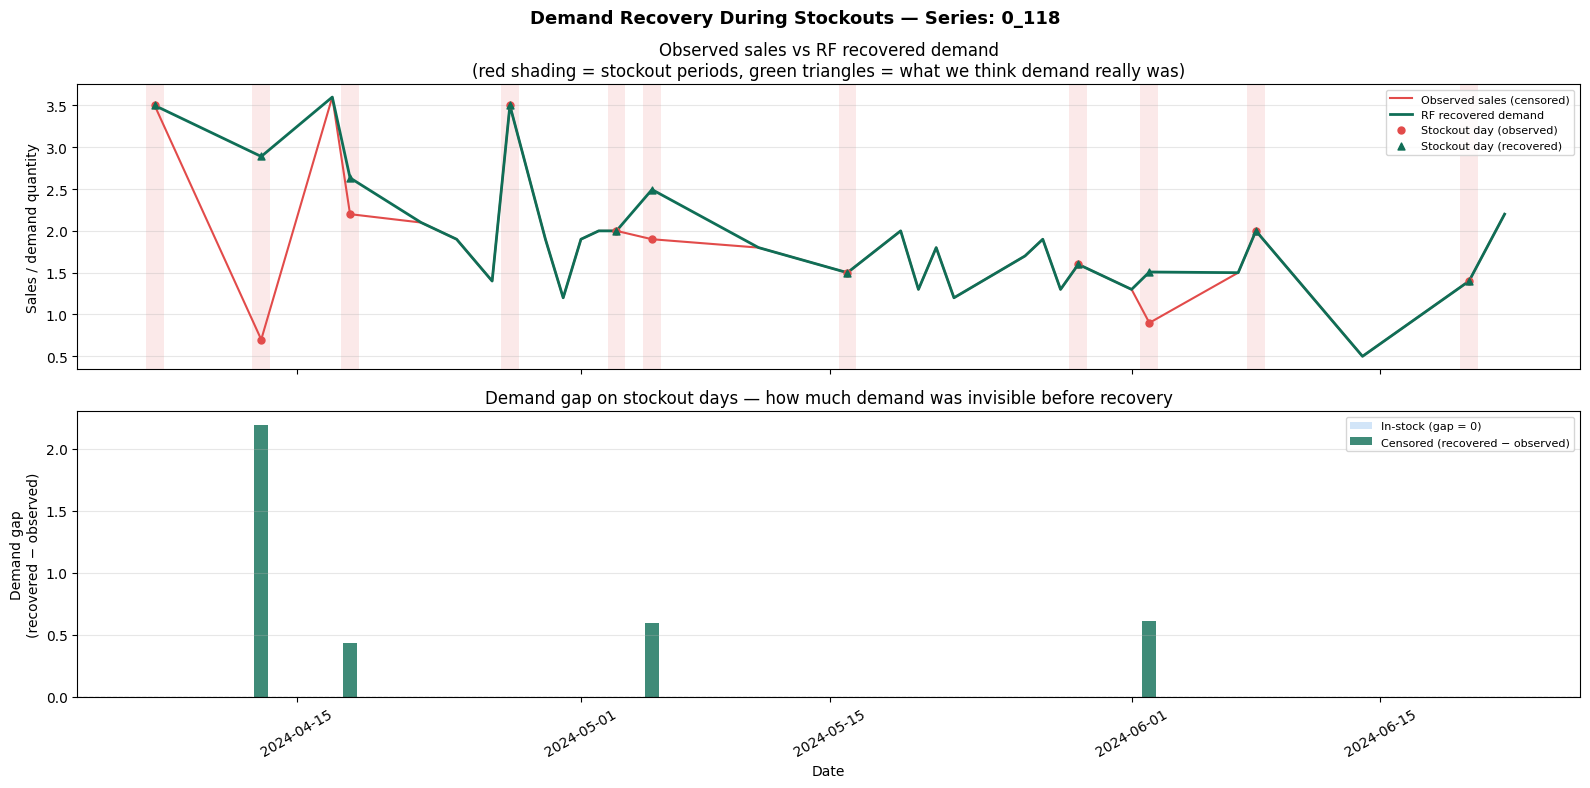

Saved: demand_recovery_single_series.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Pick one store-product pair that has actual stockout days ──
# Find a series with a mix of in-stock and censored days for a good visual
series_stats = df.groupby("series_id").agg(
    n_censored = ("is_censored", "sum"),
    n_total    = ("is_censored", "count")
).query("n_censored >= 5 and n_total >= 30")

sample_series = series_stats.index[0]  # take the first qualifying series
print(f"Plotting series: {sample_series}")

# ── Get that series sorted by date ──
series_df = (
    df[df["series_id"] == sample_series]
    .sort_values("dt")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f"Demand Recovery During Stockouts — Series: {sample_series}",
             fontsize=13, fontweight="bold")

# ── TOP PANEL: Sales lines + stockout shading ──
ax = axes[0]

ax.plot(series_df["dt"], series_df["sale_amount"],
        color="#E24B4A", linewidth=1.5, label="Observed sales (censored)", zorder=3)

ax.plot(series_df["dt"], series_df["recovered_demand"],
        color="#0F6E56", linewidth=2, label="RF recovered demand", zorder=4)

# Shade stockout periods red
stockout_rows = series_df[series_df["is_censored"] == 1]
for _, row in stockout_rows.iterrows():
    ax.axvspan(row["dt"] - pd.Timedelta(hours=12),
               row["dt"] + pd.Timedelta(hours=12),
               alpha=0.12, color="#E24B4A", linewidth=0)

# Dot the exact stockout days
ax.scatter(stockout_rows["dt"], stockout_rows["sale_amount"],
           color="#E24B4A", s=25, zorder=5, label="Stockout day (observed)")
ax.scatter(stockout_rows["dt"], stockout_rows["recovered_demand"],
           color="#0F6E56", s=25, marker="^", zorder=5, label="Stockout day (recovered)")

ax.set_ylabel("Sales / demand quantity")
ax.set_title("Observed sales vs RF recovered demand\n"
             "(red shading = stockout periods, green triangles = what we think demand really was)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(axis="y", alpha=0.3)

# ── BOTTOM PANEL: Gap (recovered - observed) only on stockout days ──
ax2 = axes[1]

gap = series_df["recovered_demand"] - series_df["sale_amount"]

# In-stock days: gap should be 0 (we kept observed sales)
ax2.bar(series_df[series_df["in_stock"] == 1]["dt"],
        gap[series_df["in_stock"] == 1],
        color="#B5D4F4", alpha=0.6, label="In-stock (gap = 0)")

# Stockout days: gap = how much demand was missed
ax2.bar(series_df[series_df["is_censored"] == 1]["dt"],
        gap[series_df["is_censored"] == 1],
        color="#0F6E56", alpha=0.8, label="Censored (recovered − observed)")

ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Demand gap\n(recovered − observed)")
ax2.set_xlabel("Date")
ax2.set_title("Demand gap on stockout days — how much demand was invisible before recovery")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("/kaggle/working/demand_recovery_single_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: demand_recovery_single_series.png")